## Exploratory Data Analysis

## 1. Standard Imports And File Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Imported')

Imported


In [4]:
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

INTERIM_DIR = "data/interim"

df_business = pd.read_json("../data/raw/yelp_json/yelp_academic_dataset_business.json", lines=True)
df_checkin  = pd.read_json("../data/raw/yelp_json/yelp_academic_dataset_checkin.json", lines=True)
df_tip      = pd.read_json("../data/raw/yelp_json/yelp_academic_dataset_tip.json", lines=True)
df_review   = pd.read_parquet(f"{INTERIM_DIR}/review.parquet")
df_user     = pd.read_parquet(f"{INTERIM_DIR}/user.parquet")

## 2. General Overview

In [10]:
df_review["date"] = pd.to_datetime(df_review["date"])
df_tip["date"] = pd.to_datetime(df_tip["date"])

def overview(df, name):
    print(f"\n{name} :")
    print("Shape:", df.shape)
    print("Memory usage:", f"{df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
    print("\nDtypes:\n", df.dtypes)
    print("\nNull counts:\n", df.isnull().sum()[df.isnull().sum() > 0])
    
    # Only check duplicates on hashable (non-dict/list) columns
    hashable_cols = [col for col in df.columns 
                      if not df[col].apply(lambda x: isinstance(x, (dict, list))).any()]
    print("\nDuplicate rows (on hashable cols):", df.duplicated(subset=hashable_cols).sum())

for name, df in [("business", df_business), ("checkin", df_checkin),
                  ("tip", df_tip), ("review", df_review), ("user", df_user)]:
    overview(df, name)


business :
Shape: (150346, 14)
Memory usage: 165.13 MB

Dtypes:
 business_id      object
name             object
address          object
city             object
state            object
postal_code      object
latitude        float64
longitude       float64
stars           float64
review_count      int64
is_open           int64
attributes       object
categories       object
hours            object
dtype: object

Null counts:
 attributes    13744
categories      103
hours         23223
dtype: int64

Duplicate rows (on hashable cols): 0

checkin :
Shape: (131930, 2)
Memory usage: 298.17 MB

Dtypes:
 business_id    object
date           object
dtype: object

Null counts:
 Series([], dtype: int64)

Duplicate rows (on hashable cols): 0

tip :
Shape: (908915, 5)
Memory usage: 267.55 MB

Dtypes:
 user_id                     object
business_id                 object
text                        object
date                datetime64[ns]
compliment_count             int64
dtype: object

Null cou

## 3. Business Table EDA

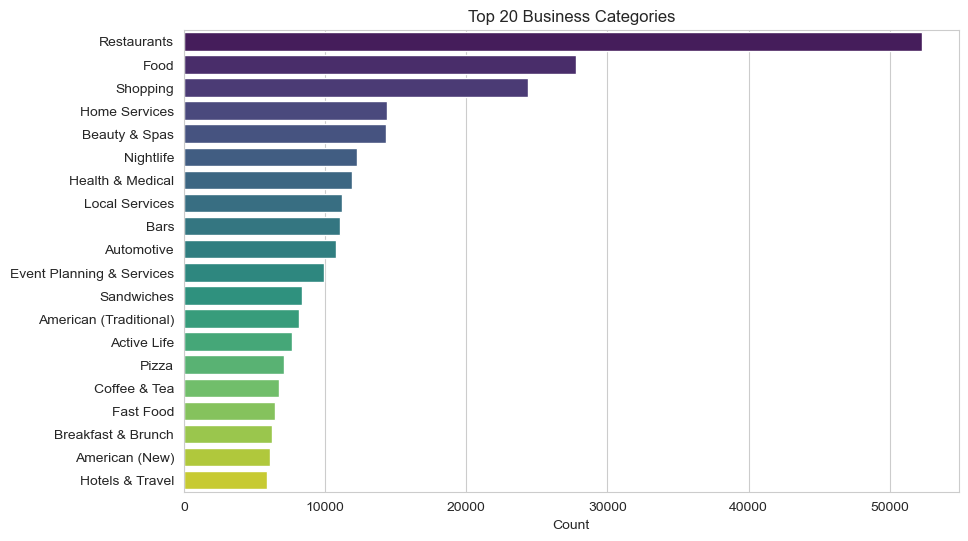

In [11]:
# Top categories
from collections import Counter

cat_series = df_business["categories"].dropna().str.split(", ")
all_cats = Counter([cat for sublist in cat_series for cat in sublist])
top_cats = pd.Series(dict(all_cats)).sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis")
plt.title("Top 20 Business Categories")
plt.xlabel("Count")
plt.show()

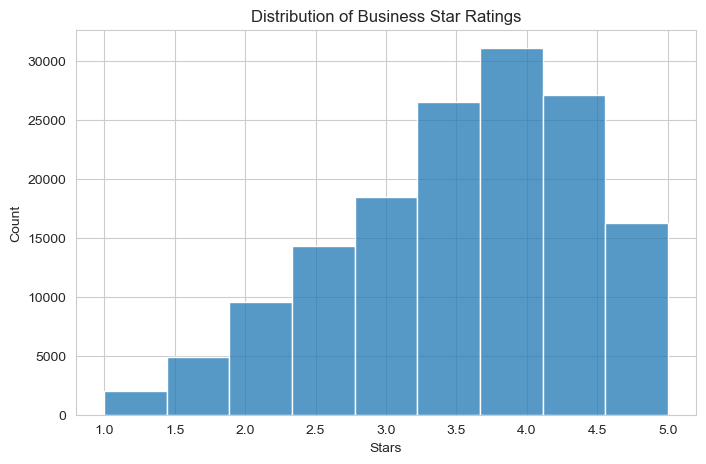

In [40]:
#Star ratings
plt.figure(figsize=(8,5))
sns.histplot(df_business["stars"], bins=9, kde=False)
plt.title("Distribution of Business Star Ratings")
plt.xlabel("Stars")
plt.show()

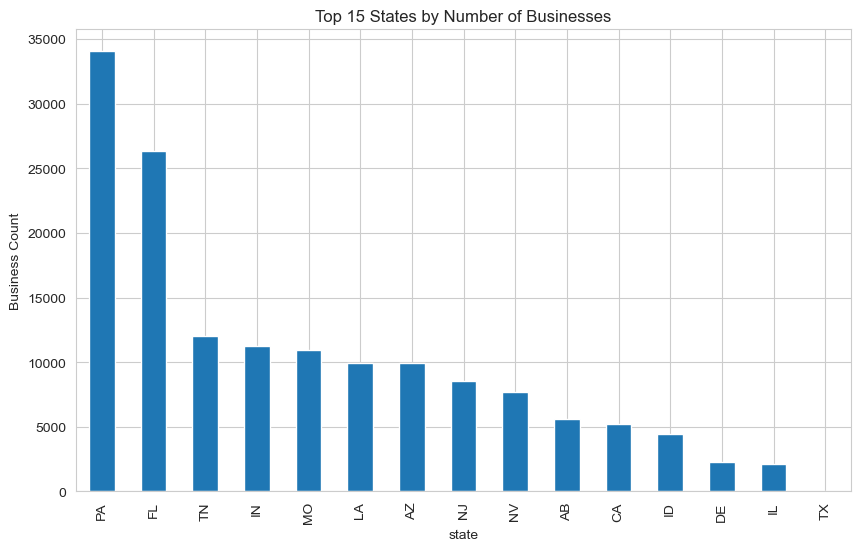

In [17]:
# Top cities/states by business count
plt.figure(figsize=(10,6))
df_business["state"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 States by Number of Businesses")
plt.ylabel("Business Count")
plt.show()

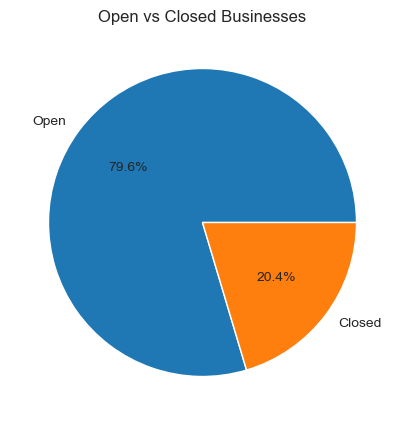

In [18]:
# Open vs closed businesses
df_business["is_open"].value_counts(normalize=True).plot(
    kind="pie", autopct="%1.1f%%", labels=["Open", "Closed"], figsize=(5,5))
plt.title("Open vs Closed Businesses")
plt.ylabel("")
plt.show()

## 4. Review Table EDA

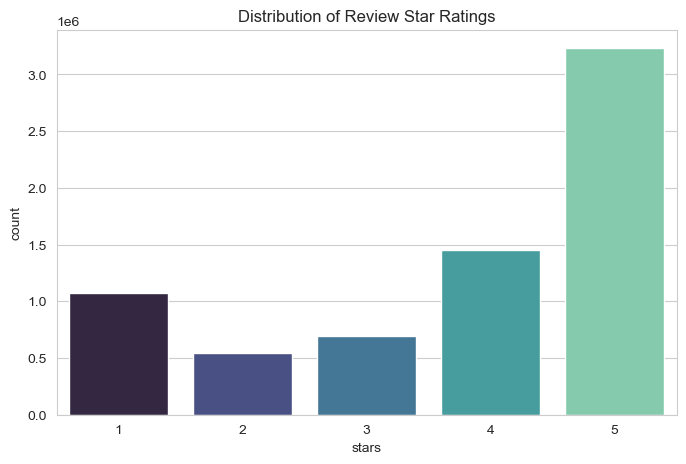

In [19]:
# Review star distribution
plt.figure(figsize=(8,5))
sns.countplot(x="stars", data=df_review, palette="mako")
plt.title("Distribution of Review Star Ratings")
plt.show()

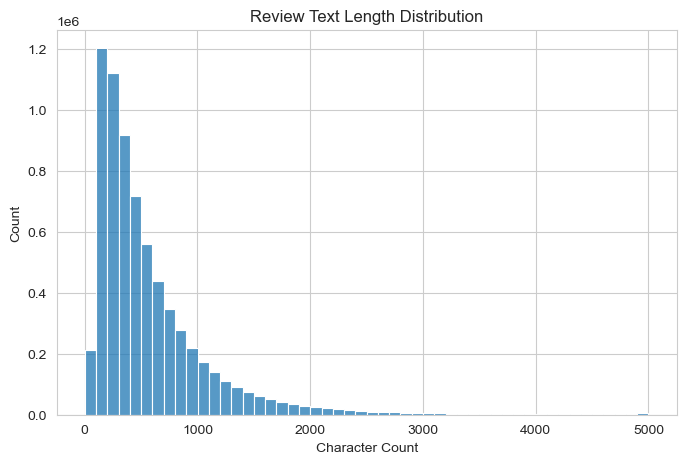

In [35]:
# Review length distribution
df_review["text_length"] = df_review["text"].str.len()
#pd.option_context('mode.use_inf_as_na', True)
plt.figure(figsize=(8,5))
sns.histplot(df_review["text_length"], bins=50)
plt.title("Review Text Length Distribution")
plt.xlabel("Character Count")
plt.show()

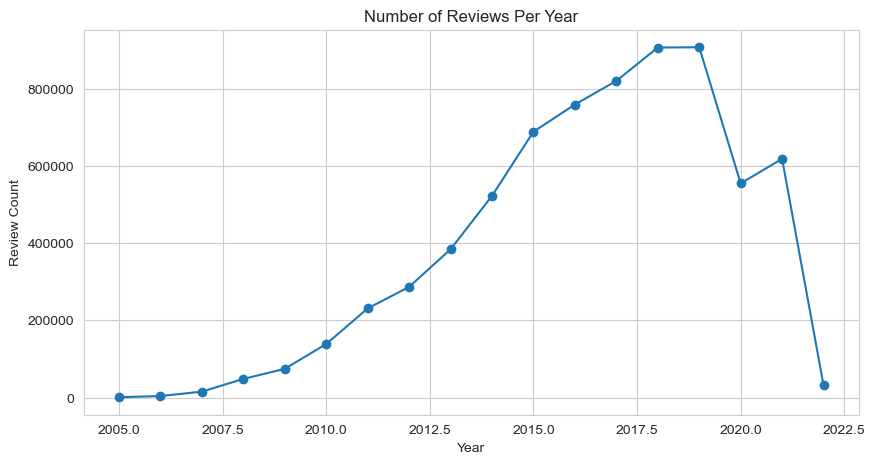

In [21]:
# Reviews over time
df_review["date"] = pd.to_datetime(df_review["date"])
reviews_per_year = df_review["date"].dt.year.value_counts().sort_index()

plt.figure(figsize=(10,5))
reviews_per_year.plot(kind="line", marker="o")
plt.title("Number of Reviews Per Year")
plt.xlabel("Year")
plt.ylabel("Review Count")
plt.show()

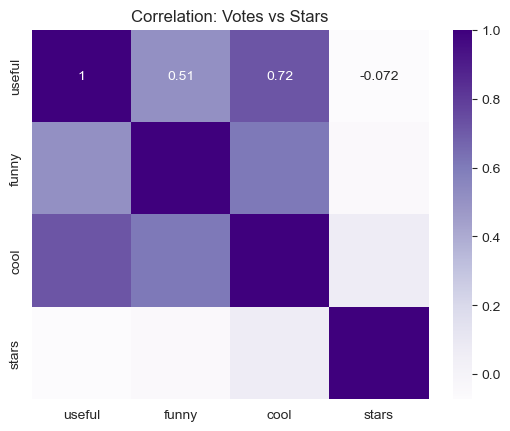

In [46]:
# Useful / funny / cool votes correlation with stars
vote_cols = ["useful", "funny", "cool", "stars"]
sns.heatmap(df_review[vote_cols].corr(), annot=True, cmap='Purples')
plt.title("Correlation: Votes vs Stars")
plt.show()

## 5. User Table EDA

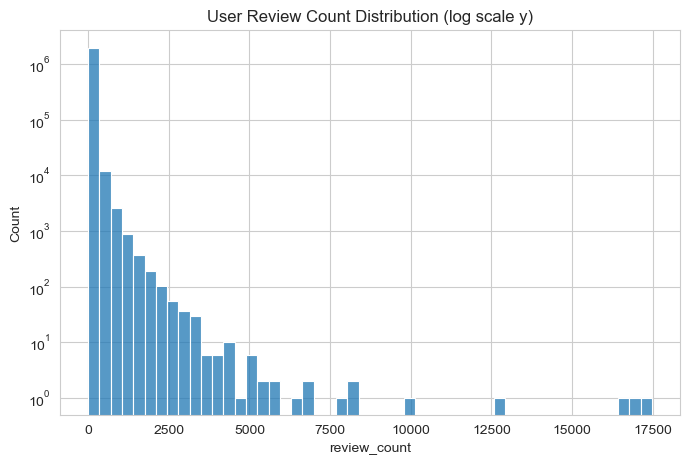

In [36]:
# Distribution of review counts per user
plt.figure(figsize=(8,5))
sns.histplot(df_user["review_count"], bins=50, log_scale=(False, True))
plt.title("User Review Count Distribution (log scale y)")
plt.show()

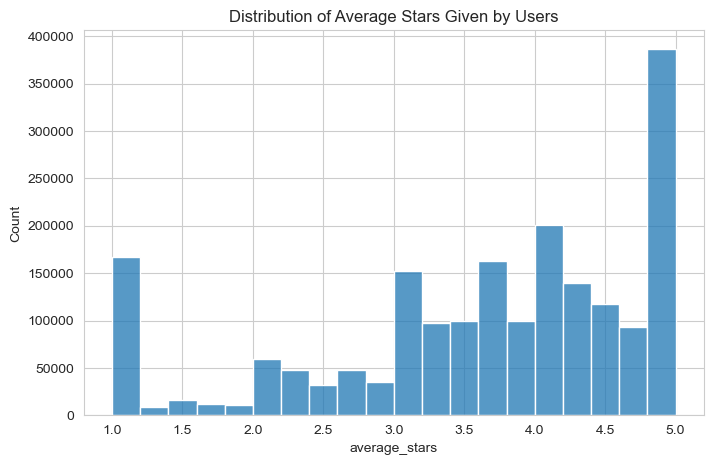

In [39]:
# Average stars given by users
plt.figure(figsize=(8,5))
sns.histplot(df_user["average_stars"], bins=20)
plt.title("Distribution of Average Stars Given by Users")
plt.show()

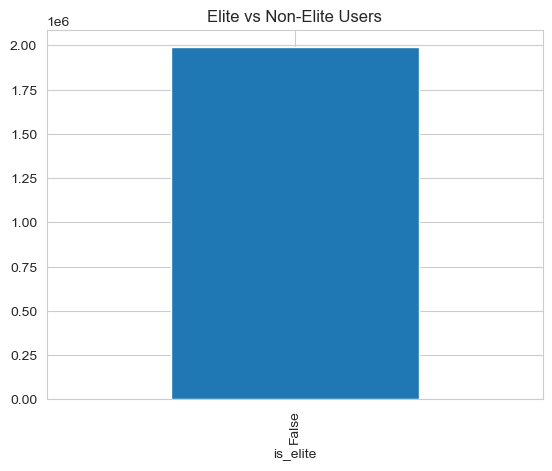

In [29]:
# Elite vs non-elite users
df_user["is_elite"] = df_user["elite"].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
df_user["is_elite"].value_counts().plot(kind="bar")
plt.title("Elite vs Non-Elite Users")
plt.show()

## 6. Checkin And Tip

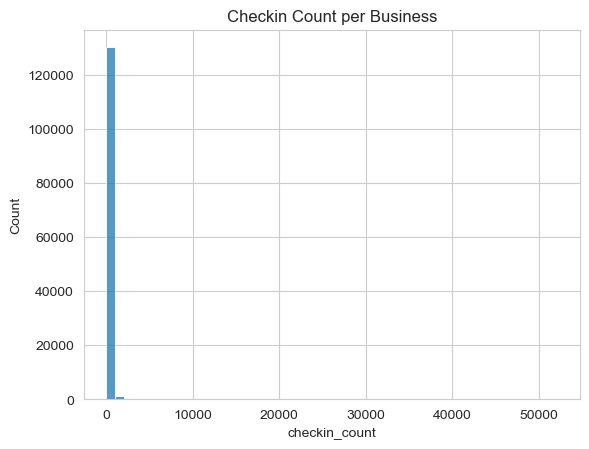

In [37]:
# Checkin frequency (count of timestamps per business)
df_checkin["checkin_count"] = df_checkin["date"].apply(lambda x: len(x.split(",")))
sns.histplot(df_checkin["checkin_count"], bins=50)
plt.title("Checkin Count per Business")
plt.show()

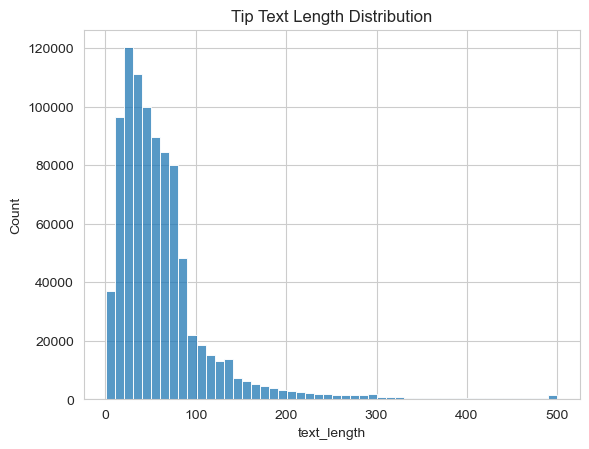

In [38]:
# Tip text length
df_tip["text_length"] = df_tip["text"].str.len()
sns.histplot(df_tip["text_length"], bins=50)
plt.title("Tip Text Length Distribution")
plt.show()

## 7. Cross Table Insight

In [33]:
# Merge business + review avg stars check
merged_check = df_business[["business_id", "stars", "review_count"]].merge(
    df_review.groupby("business_id")["stars"].mean().rename("review_avg_stars"),
    on="business_id", how="left"
)
merged_check.head()

,business_id,stars,review_count,review_avg_stars
0,Pns2l4eNsfO8kk83dixA6A,5.0,7,4.857143
1,mpf3x-BjTdTEA3yCZrAYPw,3.0,15,3.133333
2,tUFrWirKiKi_TAnsVWINQQ,3.5,22,3.500000
3,MTSW4McQd7CbVtyjqoe9mw,4.0,80,4.057471
4,mWMc6_wTdE0EUBKIGXDVfA,4.5,13,4.692308
